In [1]:
import numpy as np, camb, local, importlib
from matplotlib.pyplot import *
from scipy.interpolate import RectBivariateSpline

In [88]:
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/rotation/pmf-bispec/local.py'>

In [3]:
# --- CAMB calculation ---
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
lmax = 2000
pars.set_for_lmax(lmax, lens_potential_accuracy=0)
# for all ell, pars.Accuracy.lSampleBoost = 50
data = camb.get_transfer_functions(pars)
transfer = data.get_cmb_transfer_data()
# --- temperature transfer function ---
ells, ks, T_lk = transfer.get_transfer(source=0)
results = camb.get_results(pars)
eta0 = results.conformal_time(0)

In [4]:
T_spline = RectBivariateSpline(ells.astype(float),np.log(ks),T_lk,kx=3,ky=3)
def Delta_T(ell, k):
    ell = np.asarray(ell, dtype=float)
    k = np.asarray(k, dtype=float)
    if np.any(k <= 0):
        raise ValueError("k must be positive.")
    if np.any(k < ks.min()) or np.any(k > ks.max()):
        raise ValueError(f"k is outside CAMB grid: {ks.min()} <= k <= {ks.max()}")
    if np.any(ell < ells.min()) or np.any(ell > ells.max()):
        raise ValueError(f"ell is outside CAMB grid: {ells.min()} <= ell <= {ells.max()}")
    return T_spline.ev(ell, np.log(k))

In [5]:
k_arr = np.logspace(-5,-1.5,1000)

In [6]:
ell_B, ks_B, TB_lk = local.compute_transfer_B()

In [7]:
lmaxB = ell_B.max()

In [8]:
TB_spline = RectBivariateSpline(ell_B.astype(float),np.log(ks_B),TB_lk,kx=3,ky=3)
def Delta_B(ell, k):
    ell = np.asarray(ell, dtype=float)
    k = np.asarray(k, dtype=float)
    if np.any(k <= 0):
        raise ValueError("k must be positive.")
    if np.any(k < ks_B.min()) or np.any(k > ks_B.max()):
        raise ValueError(f"k is outside CAMB grid: {ks_B.min()} <= k <= {ks_B.max()}")
    if np.any(ell < ell_B.min()) or np.any(ell > ell_B.max()):
        raise ValueError(f"ell is outside CAMB grid: {ell_B.min()} <= ell <= {ell_B.max()}")
    return TB_spline.ev(ell, np.log(k))

In [9]:
r_grid = np.logspace(2,5,50)

In [10]:
Xi = local.Xi_func(2000, r_grid, eta0, -2.9, kn=100)

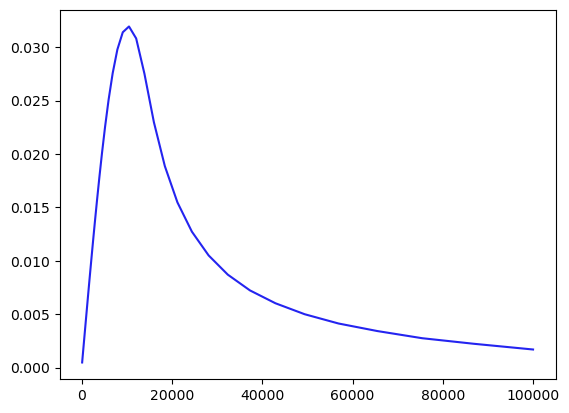

In [11]:
plot(r_grid,Xi[(2,'E')](r_grid))